# 01 — Exploratory Data Analysis

Goal: understand the synthetic dataset before throwing models at it. Confirm:

1. Failure types are present and distributed roughly as expected.
2. Healthy vs failing miners look visibly different in the raw telemetry.
3. The True Efficiency KPI separates healthy from failing better than plain J/TH.
4. The `is_pre_failure` label (post Apr 8 fix) is aligned with the actual degradation phase.
5. Sensor signals correlate the way physics says they should.

All cells run against `data/raw/mining_telemetry.parquet`. Run `uv run python -m src.run_pipeline` first if the parquet doesn't exist.

In [1]:
import sys
from pathlib import Path

# Make src.* importable when running from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import RAW_DIR

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', 40)

Matplotlib is building the font cache; this may take a moment.


## 1. Load and inspect

In [2]:
raw_path = RAW_DIR / 'mining_telemetry.parquet'
assert raw_path.exists(), f'Missing {raw_path}. Run the pipeline first.'

# Load only the columns we need for EDA to keep memory low.
cols = [
    'timestamp', 'miner_id', 'model', 'container_id',
    'clock_frequency_mhz', 'voltage_v', 'hashrate_th', 'temperature_c',
    'power_w', 'ambient_temperature_c', 'operating_mode',
    'failure_type', 'is_pre_failure', 'degradation_phase',
]
df = pd.read_parquet(raw_path, columns=cols)
print(f'Loaded {len(df):,} rows × {len(df.columns)} cols')
print(f'Time range: {df["timestamp"].min()} → {df["timestamp"].max()}')
print(f'Miners: {df["miner_id"].nunique()}')
print(f'Containers: {df["container_id"].nunique()}')
print(f'Models: {df["model"].unique().tolist()}')

Loaded 5,184,000 rows × 14 cols
Time range: 2026-01-01 00:00:00 → 2026-04-30 23:59:00


Miners: 30


Containers: 3
Models: ['Pro', 'M56S', 'M63', 'XP']


## 2. Failure type distribution

In [3]:
ft_counts = df['failure_type'].value_counts()
print('Rows by failure_type:')
print(ft_counts)
print()
print(f'Healthy rows: {ft_counts.get("none", 0):,} ({ft_counts.get("none", 0)/len(df)*100:.1f}%)')
print(f'Failure rows: {len(df) - ft_counts.get("none", 0):,}')

# Distinct failing miners per type
print('\nDistinct miners per failure type:')
for ft in ft_counts.index:
    if ft == 'none':
        continue
    n = df[df['failure_type'] == ft]['miner_id'].nunique()
    print(f'  {ft:25s} {n}')

Rows by failure_type:
failure_type
none                   4761635
connector_corrosion     187476
psu_degradation         150604
thermal_runaway          26716
gradual_degradation      21041
coolant_restriction      20968
fan_stall                15548
sudden_chip_failure         12
Name: count, dtype: int64

Healthy rows: 4,761,635 (91.9%)
Failure rows: 422,365

Distinct miners per failure type:
  connector_corrosion       3


  psu_degradation           2
  thermal_runaway           3


  gradual_degradation       1
  coolant_restriction       1


  fan_stall                 1
  sudden_chip_failure       4


In [4]:
# Phase distribution
phase_counts = df['degradation_phase'].value_counts()
print('Rows by degradation_phase:')
print(phase_counts)

Rows by degradation_phase:
degradation_phase
healthy         4761635
incubation       227524
failed           121738
acceleration      65498
cascade            7605
Name: count, dtype: int64


## 3. Verify the label fix

Post Apr 8: `is_pre_failure` should equal `degradation_phase ∈ {incubation, acceleration}`.
Before the fix, ~53% of pre-failure rows were stamped on `degradation_phase=='healthy'` rows.

In [5]:
pre = df[df['is_pre_failure']]
print(f'Total pre-failure rows: {len(pre):,} ({len(pre)/len(df)*100:.2f}% of all rows)')
print()
print('Cross-tab: failure_type × degradation_phase (pre-failure rows only)')
print(pd.crosstab(pre['failure_type'], pre['degradation_phase'], margins=True))
print()

# Sanity asserts
healthy_positives = (pre['degradation_phase'] == 'healthy').sum()
print(f'Pre-failure rows with degradation_phase==healthy: {healthy_positives}')
assert healthy_positives == 0, 'Label fix broken: pre-failure stamped on healthy rows'

phase_positives = df[df['degradation_phase'].isin(['incubation', 'acceleration'])]
missing = (~phase_positives['is_pre_failure']).sum()
print(f'Incubation/acceleration rows NOT marked pre-failure: {missing}')
assert missing == 0, 'Label fix broken: degrading rows not labeled'
print()
print('Label fix verified ✓')

Total pre-failure rows: 293,022 (5.65% of all rows)

Cross-tab: failure_type × degradation_phase (pre-failure rows only)


degradation_phase    acceleration  incubation     All
failure_type                                         
connector_corrosion         30240       90720  120960
coolant_restriction           808       20160   20968
fan_stall                    1148       14400   15548
gradual_degradation           881       20160   21041
psu_degradation             28800       60480   89280
sudden_chip_failure             4           4       8
thermal_runaway              3617       21600   25217
All                         65498      227524  293022

Pre-failure rows with degradation_phase==healthy: 0


Incubation/acceleration rows NOT marked pre-failure: 0

Label fix verified ✓


## 4. Healthy vs failing miner — visual comparison

Pick one healthy miner and one failing miner, plot their key signals over time. The failing miner should show a visible departure from healthy patterns starting at incubation.

In [6]:
# Pick two miners: one with no failure, one with the longest failure window
miner_failure_size = df[df['is_pre_failure']].groupby('miner_id').size().sort_values(ascending=False)
if len(miner_failure_size) > 0:
    failing_miner = miner_failure_size.index[0]
else:
    failing_miner = None

healthy_candidates = df[df['failure_type'] == 'none']['miner_id'].unique()
healthy_miner = healthy_candidates[0] if len(healthy_candidates) > 0 else None

print(f'Healthy miner: {healthy_miner}')
print(f'Failing miner: {failing_miner}')

Healthy miner: MNR-001
Failing miner: MNR-012


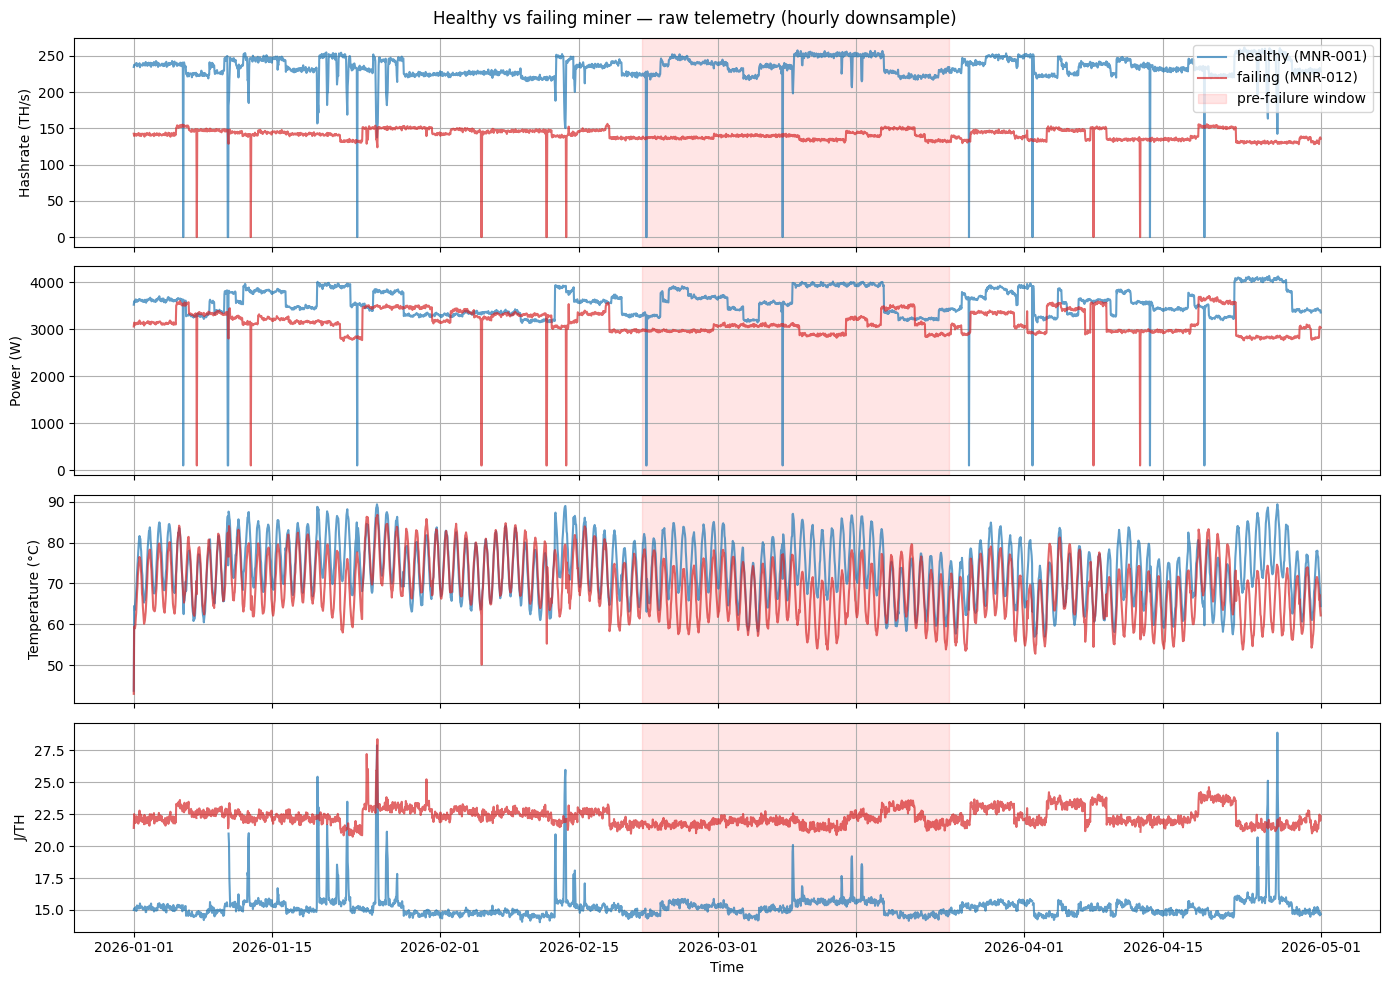

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

for label, miner_id, color in [('healthy', healthy_miner, 'tab:blue'),
                                ('failing', failing_miner, 'tab:red')]:
    if miner_id is None:
        continue
    m = df[df['miner_id'] == miner_id].sort_values('timestamp')
    # Downsample for plotting (1 point per hour)
    m_hr = m.iloc[::60]
    axes[0].plot(m_hr['timestamp'], m_hr['hashrate_th'], label=f'{label} ({miner_id})', color=color, alpha=0.7)
    axes[1].plot(m_hr['timestamp'], m_hr['power_w'], color=color, alpha=0.7)
    axes[2].plot(m_hr['timestamp'], m_hr['temperature_c'], color=color, alpha=0.7)
    jth = m_hr['power_w'] / m_hr['hashrate_th'].replace(0, np.nan)
    axes[3].plot(m_hr['timestamp'], jth, color=color, alpha=0.7)

    if label == 'failing':
        # Shade pre-failure window
        pf = m[m['is_pre_failure']]
        if len(pf) > 0:
            for ax in axes:
                ax.axvspan(pf['timestamp'].min(), pf['timestamp'].max(),
                           color='red', alpha=0.1, label='pre-failure window' if ax == axes[0] else None)

axes[0].set_ylabel('Hashrate (TH/s)')
axes[1].set_ylabel('Power (W)')
axes[2].set_ylabel('Temperature (°C)')
axes[3].set_ylabel('J/TH')
axes[0].legend(loc='upper right')
axes[3].set_xlabel('Time')
plt.suptitle('Healthy vs failing miner — raw telemetry (hourly downsample)')
plt.tight_layout()
plt.show()

## 5. True Efficiency vs naive J/TH

The whole point of TE_health is that it separates healthy from failing miners better than raw J/TH. Compare the two distributions across the fleet.

In [8]:
from src.kpi.true_efficiency import compute_all_te_variants

df_te = compute_all_te_variants(df)
df_te['jth'] = np.where(df_te['hashrate_th'] > 0, df_te['power_w'] / df_te['hashrate_th'], np.nan)

is_failing = df_te['failure_type'] != 'none'

print('Mean J/TH:')
print(f'  healthy: {df_te.loc[~is_failing, "jth"].mean():.2f}')
print(f'  failing: {df_te.loc[is_failing, "jth"].mean():.2f}')
print(f'  separation: {(df_te.loc[is_failing, "jth"].mean() / df_te.loc[~is_failing, "jth"].mean() - 1) * 100:.1f}%')
print()
print('Mean TE_health:')
print(f'  healthy: {df_te.loc[~is_failing, "te_health"].mean():.6f}')
print(f'  failing: {df_te.loc[is_failing, "te_health"].mean():.6f}')
print(f'  separation: {(df_te.loc[~is_failing, "te_health"].mean() / max(df_te.loc[is_failing, "te_health"].mean(), 1e-10) - 1) * 100:.1f}%')

Mean J/TH:
  healthy: 21.38
  failing: 24.71
  separation: 15.6%

Mean TE_health:


  healthy: 0.015521
  failing: 0.004868
  separation: 218.8%


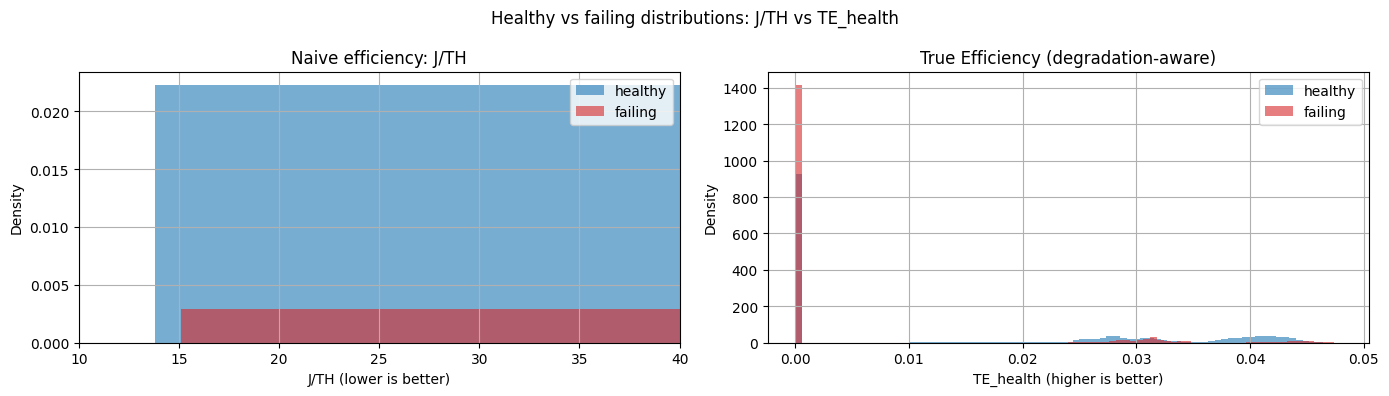

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_te.loc[~is_failing, 'jth'].dropna(), bins=80, alpha=0.6, label='healthy', color='tab:blue', density=True)
axes[0].hist(df_te.loc[is_failing, 'jth'].dropna(), bins=80, alpha=0.6, label='failing', color='tab:red', density=True)
axes[0].set_xlabel('J/TH (lower is better)')
axes[0].set_ylabel('Density')
axes[0].set_title('Naive efficiency: J/TH')
axes[0].legend()
axes[0].set_xlim(10, 40)

axes[1].hist(df_te.loc[~is_failing, 'te_health'].dropna(), bins=80, alpha=0.6, label='healthy', color='tab:blue', density=True)
axes[1].hist(df_te.loc[is_failing, 'te_health'].dropna(), bins=80, alpha=0.6, label='failing', color='tab:red', density=True)
axes[1].set_xlabel('TE_health (higher is better)')
axes[1].set_ylabel('Density')
axes[1].set_title('True Efficiency (degradation-aware)')
axes[1].legend()

plt.suptitle('Healthy vs failing distributions: J/TH vs TE_health')
plt.tight_layout()
plt.show()

## 6. Sensor signal correlations (healthy miners only)

Sanity check that the physics is sane. We should see:
- Frequency ↔ hashrate strong positive
- Frequency ↔ power strong positive (P = CV²f)
- Power ↔ temperature positive (more power, more heat)
- Ambient temperature ↔ chip temperature positive (RC thermal model)

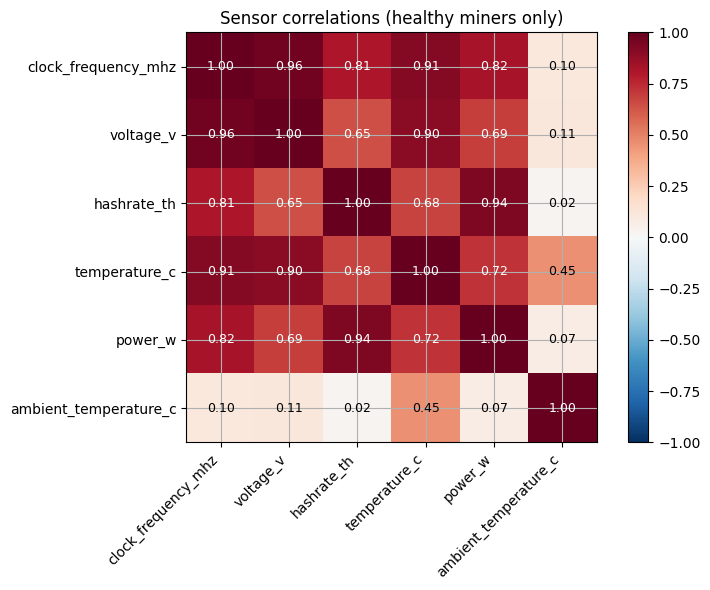

In [10]:
sensor_cols = ['clock_frequency_mhz', 'voltage_v', 'hashrate_th',
               'temperature_c', 'power_w', 'ambient_temperature_c']
healthy = df[df['failure_type'] == 'none']
# Subsample to keep correlation matrix fast
sample = healthy.sample(n=min(len(healthy), 200_000), random_state=42)
corr = sample[sensor_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(sensor_cols)))
ax.set_yticks(range(len(sensor_cols)))
ax.set_xticklabels(sensor_cols, rotation=45, ha='right')
ax.set_yticklabels(sensor_cols)
for i in range(len(sensor_cols)):
    for j in range(len(sensor_cols)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr.values[i, j]) > 0.5 else 'black', fontsize=9)
plt.colorbar(im, ax=ax)
plt.title('Sensor correlations (healthy miners only)')
plt.tight_layout()
plt.show()

## 7. Per-miner failure timeline

Show when each miner enters incubation/acceleration/cascade. Useful for understanding why the adaptive temporal split places boundaries where it does.

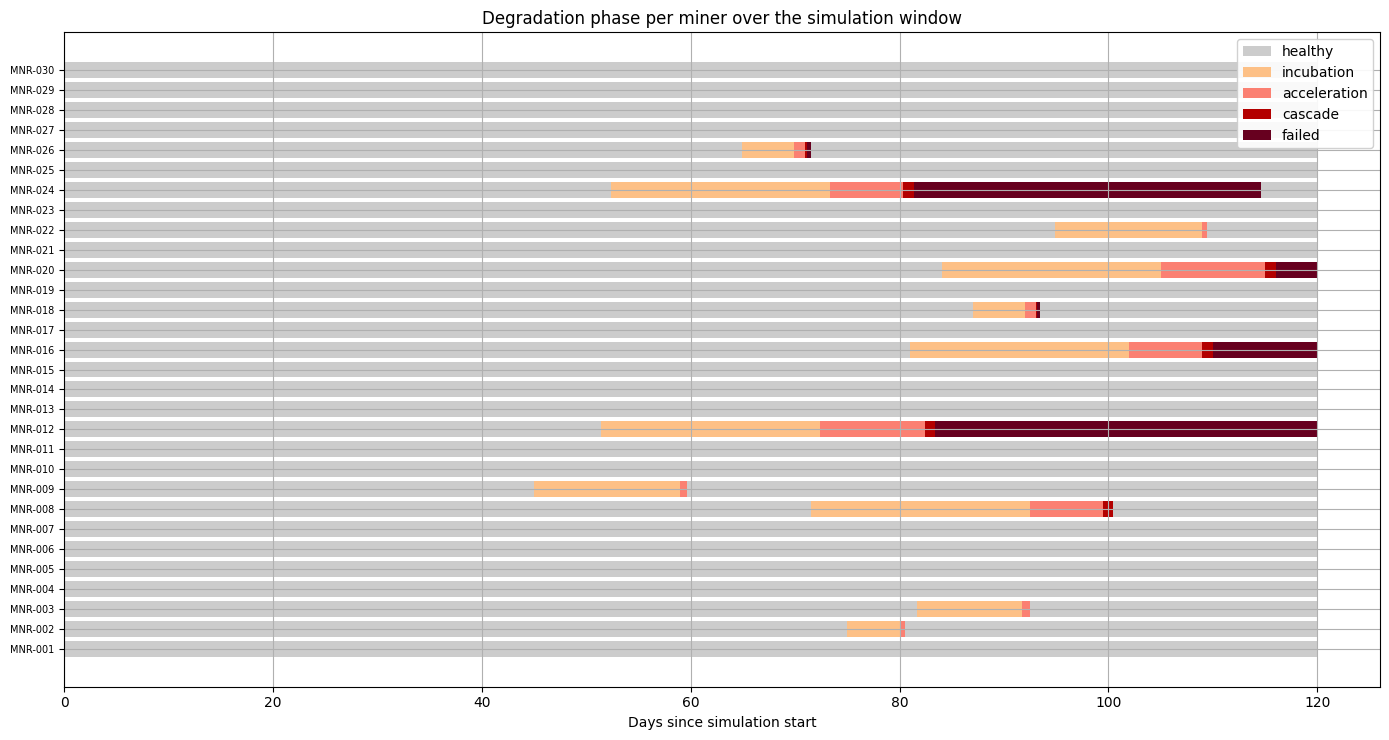

In [11]:
phase_colors = {'healthy': '#cccccc', 'incubation': '#fdc086',
                'acceleration': '#fb8072', 'cascade': '#b30000', 'failed': '#67001f'}

miners = sorted(df['miner_id'].unique())
fig, ax = plt.subplots(figsize=(14, max(6, len(miners) * 0.25)))

for i, m in enumerate(miners):
    md = df[df['miner_id'] == m].sort_values('timestamp')
    # Find runs of same phase to plot as horizontal bars
    phases = md['degradation_phase'].values
    times = md['timestamp'].values
    if len(phases) == 0:
        continue
    starts = [0]
    for j in range(1, len(phases)):
        if phases[j] != phases[j-1]:
            starts.append(j)
    starts.append(len(phases))
    for k in range(len(starts) - 1):
        s, e = starts[k], starts[k+1]
        ph = phases[s]
        ax.barh(i, (times[e-1] - times[s]) / np.timedelta64(1, 'D'),
                left=(times[s] - times[0]) / np.timedelta64(1, 'D'),
                color=phase_colors.get(ph, '#888888'),
                edgecolor='none', height=0.8)

ax.set_yticks(range(len(miners)))
ax.set_yticklabels(miners, fontsize=7)
ax.set_xlabel('Days since simulation start')
ax.set_title('Degradation phase per miner over the simulation window')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=p) for p, c in phase_colors.items()]
ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()

## 8. Summary takeaways

Walking away from the EDA, the headline claims for the rest of the project are:

1. **The synthetic data is physics-plausible.** Sensor correlations match what we'd expect from the model `P = CV²f + leakage(T)` and the RC thermal model.
2. **The label fix held.** Every `is_pre_failure=True` row sits inside the actual `incubation` or `acceleration` phase. There are no "phantom" pre-failure rows on healthy telemetry anymore.
3. **TE_health beats J/TH.** The TE distribution shows a clearer healthy/failing separation than naive J/TH, justifying the KPI design.
4. **Failures are clustered, not uniform.** The per-miner phase timeline shows why a fixed-fraction temporal split would have put zero positives in val. The adaptive split-by-positives is necessary, not just nice.
5. **Failure types are imbalanced.** Some types (`connector_corrosion`, `psu_degradation`) dominate by row count. This drives why the multi-class refactor (F12 in REMAINING_FIXES.md) is on the followup list — the binary model has a harder time on the minority types.